In [40]:
import random

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from utils.config import Config
from data_handler import DataHandler
# from classificators.dummy_classifier import DummyClassifier
# from classificators.random_forest_classifier import RandomForestClassifierSK
# from utils.utils import calculate_mcc_multilabel, plot_per_class_confusion


In [29]:
config = Config()

# Seeding
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
# if you use any other libraries that require seeding, set it here as well (e.g., torch.manual_seed(SEED) for PyTorch)
# -> your results should be reproducible across runs with the same seed


val_mccs = []
test_mccs = []
lr_histories_by_fold = {}

# load data
datahandler = DataHandler(config=config)


Local dataset found: data\cps_data_multi_label.pkl
Loading data into memory...
Data loaded.


In [52]:

# Leave-one-out: EXPERIMENT_ID = 1..4
for fold in range(1, 2):
    val_id = fold + 1 if fold < 4 else 1

    datahandler.config.data.test_experiment_id = fold
    # validation hat to be different from test
    datahandler.config.data.validation_experiment_id = val_id

    train, val, test, target_vals = datahandler.get_data_loaders()
    print("Full Data Shape")
    print(train.shape, val.shape, test.shape)
    print("Target columns:", target_vals)
    print("Train columns:", train.columns.tolist())
    print(train.isna().sum())
    X_train = train.iloc[:, :8]
    y_train = train.iloc[:, 8:]
    X_val = val.iloc[:, :8]
    y_val = val.iloc[:, 8:]
    X_test = test.iloc[:, :8]
    y_test = test.iloc[:, 8:]

Starting data preparation...
Full Data Shape
(2136599, 15) (941667, 15) (1108546, 15)
Target columns: ['Driving(curve)', 'Driving(straight)', 'Lifting(lowering)', 'Lifting(raising)', 'Stationary processes', 'Turntable wrapping']
Train columns: ['time', 'Acc.x', 'Acc.y', 'Acc.z', 'Gyro.x', 'Gyro.y', 'Gyro.z', 'Baro.x', 'No loading', 'Driving(straight)', 'Driving(curve)', 'Lifting(raising)', 'Lifting(lowering)', 'Turntable wrapping', 'Stationary processes']
time                    0
Acc.x                   0
Acc.y                   0
Acc.z                   0
Gyro.x                  0
Gyro.y                  0
Gyro.z                  0
Baro.x                  0
No loading              0
Driving(straight)       0
Driving(curve)          0
Lifting(raising)        0
Lifting(lowering)       0
Turntable wrapping      0
Stationary processes    0
dtype: int64


In [ ]:
def plot_sensor_data_over_time(X_train):
    plt.figure(figsize=(12, 10))
    plt.plot(X_train['time'], X_train['Acc.x'], label='Acc_x')
    plt.plot(X_train['time'], X_train['Acc.y'], label='Acc_y')
    plt.plot(X_train['time'], X_train['Acc.z'], label='Acc_z')
    plt.plot(X_train['time'], X_train['Gyro.x'], label='Gyro_x')
    plt.plot(X_train['time'], X_train['Gyro.y'], label='Gyro_y')
    plt.plot(X_train['time'], X_train['Gyro.z'], label='Gyro_z')
    # plt.plot(X_train['time'], X_train['Baro.x'], label='Baro_x')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.legend()
    plt.show()


In [50]:
def plot_sensor_correlation(X_train):
    plt.figure(figsize=(12, 10))
    corr = X_train[['Acc.x','Acc.y','Acc.z','Gyro.x','Gyro.y','Gyro.z','Baro.x']].corr()
    return sns.heatmap(corr, annot=True)

In [ ]:
def plot_sensor_data_by_label(X_train, y_train, label_cols):
    for col in label_cols:
        filter_0_df = X_train[y_train[col] == 0]
        filter_1_df = X_train[y_train[col] == 1]
        plt.title(f"Sensor data over time for label {col}")
        plot_sensor_data_over_time(filter_0_df)
        plot_sensor_data_over_time(filter_1_df)
def plot_sensor_correlation_by_label(X_train, y_train, label_cols):
    for col in label_cols:
        if y_train[col].sum() == 0:
            print(f"Label [{col}] has no positive samples in the training set, skipping correlation plot.")
            continue
        filter_df = X_train[y_train[col] == 1]
        plt.title(f"Correlation of sensor data for label {col}")
        plot_sensor_correlation(filter_df)


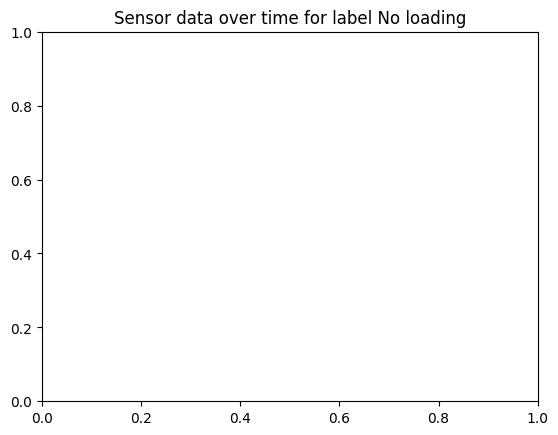

c:\Users\Kirupa Krishan G\OneDrive\Attachments\TU Dortmund\Pal2Sim\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


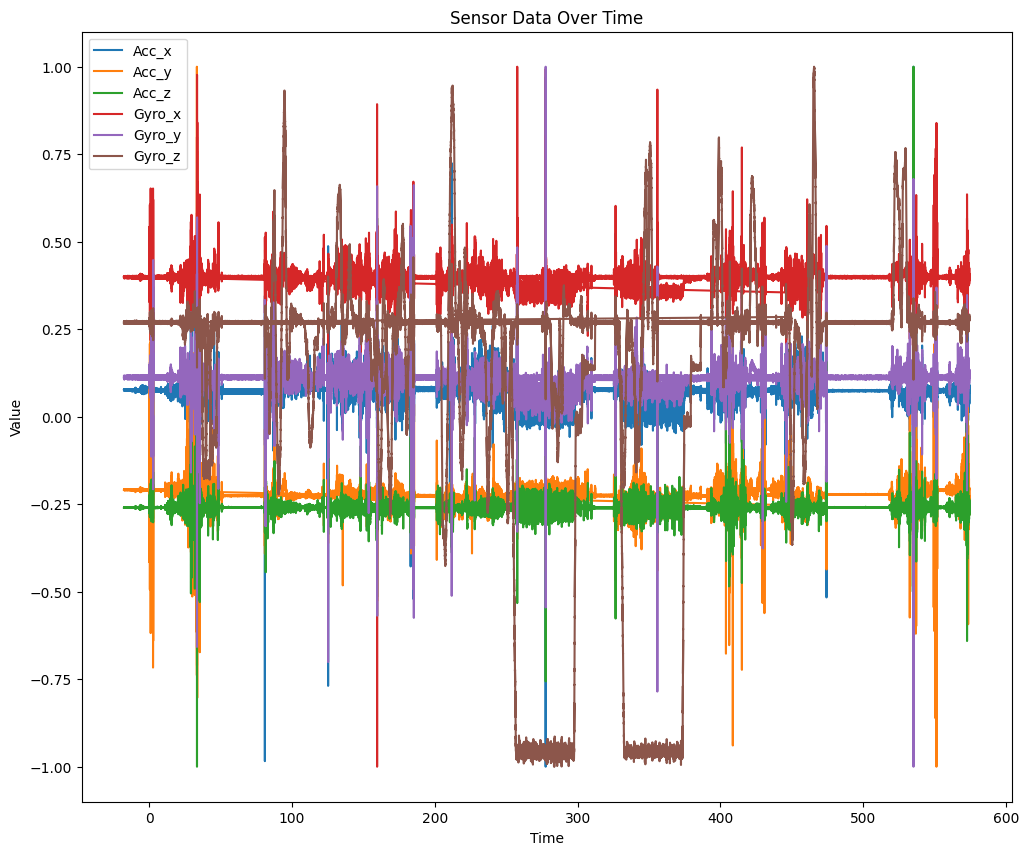

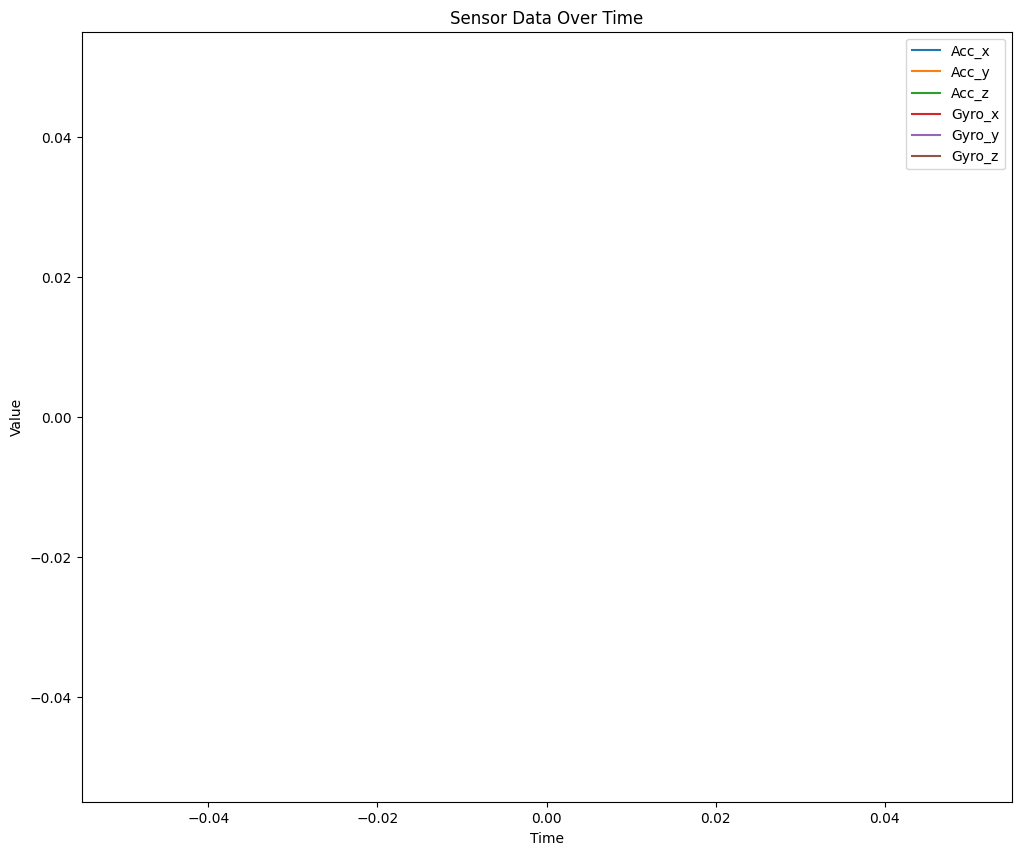

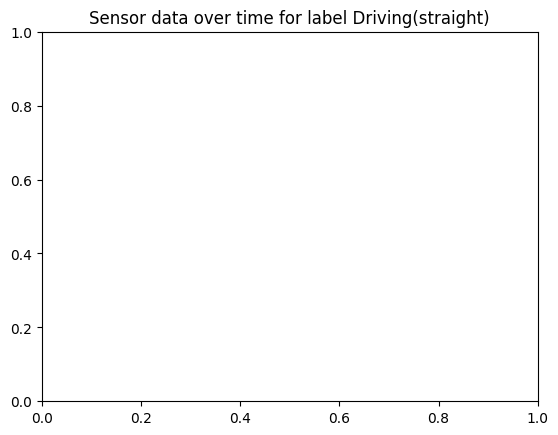

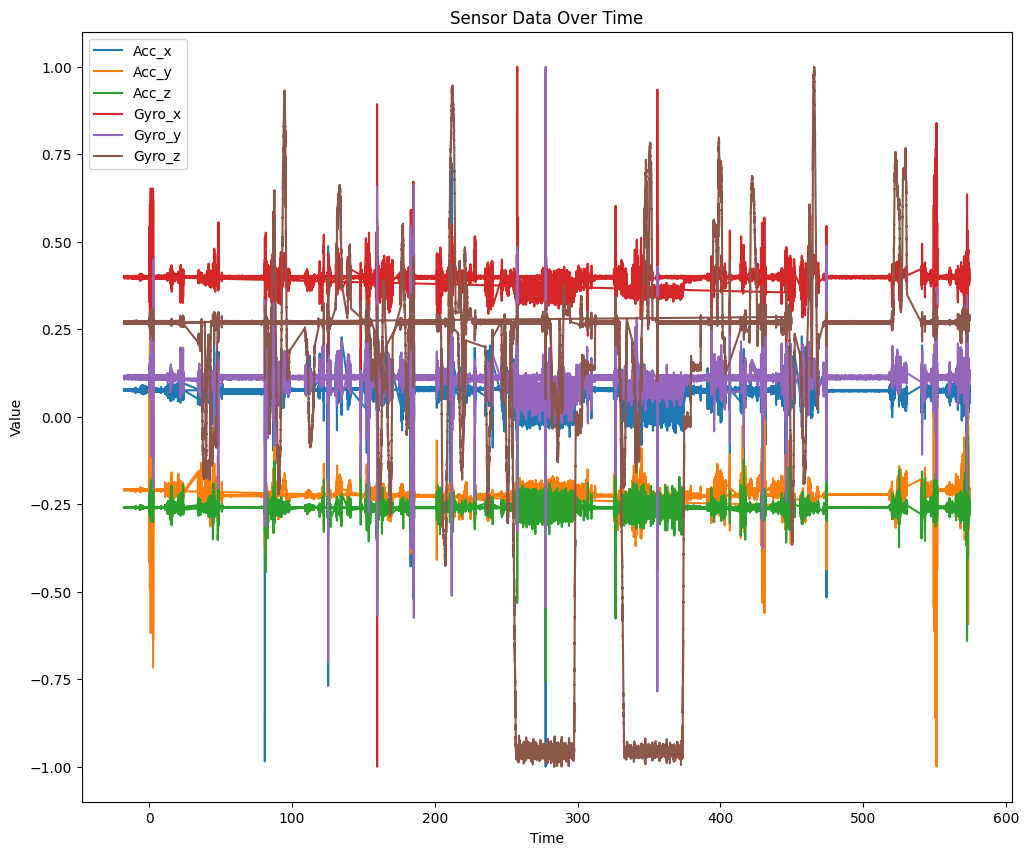

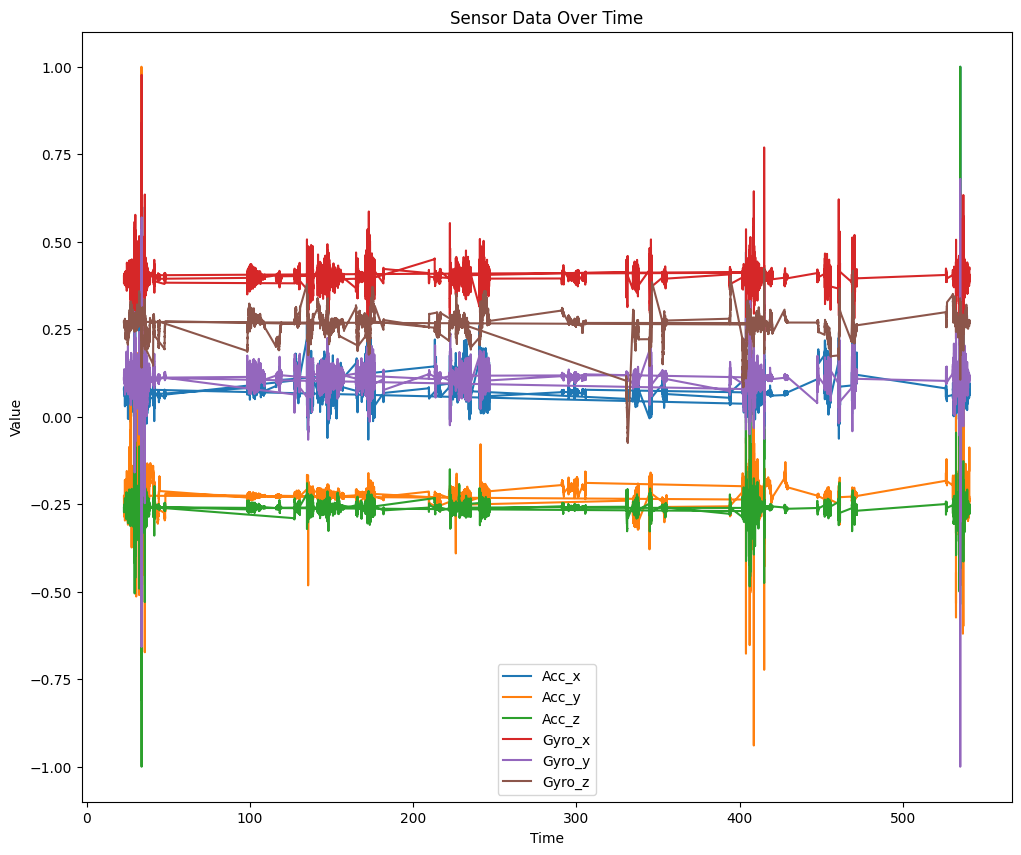

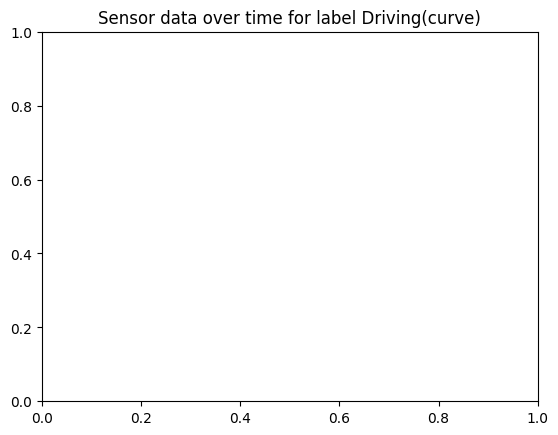

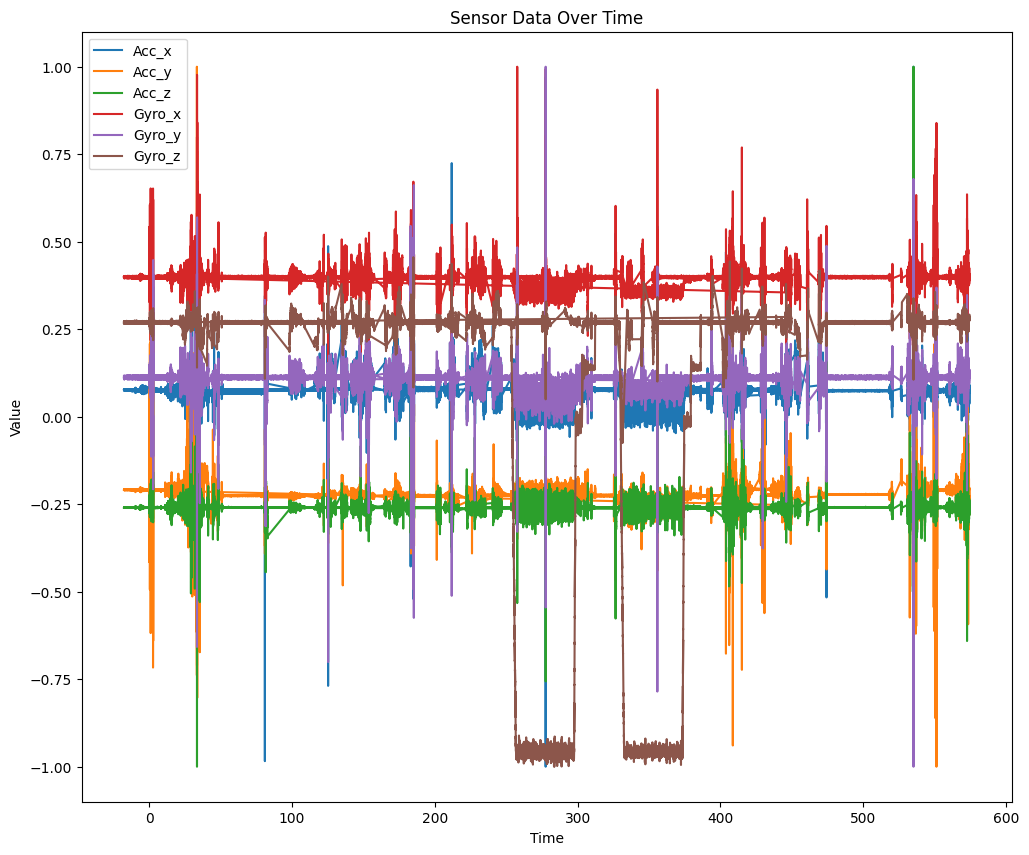

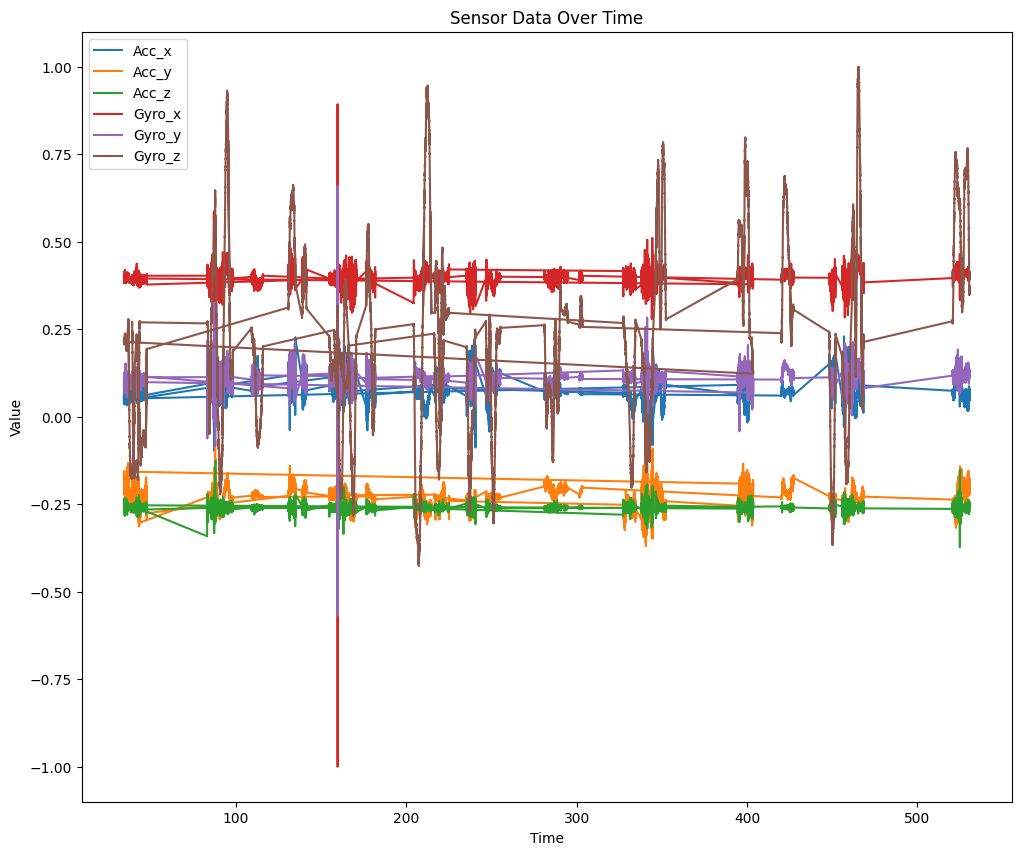

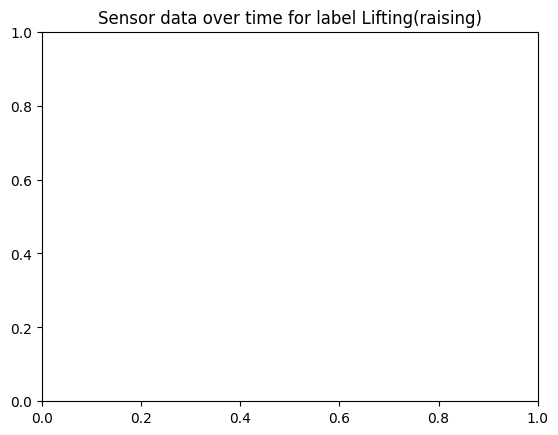

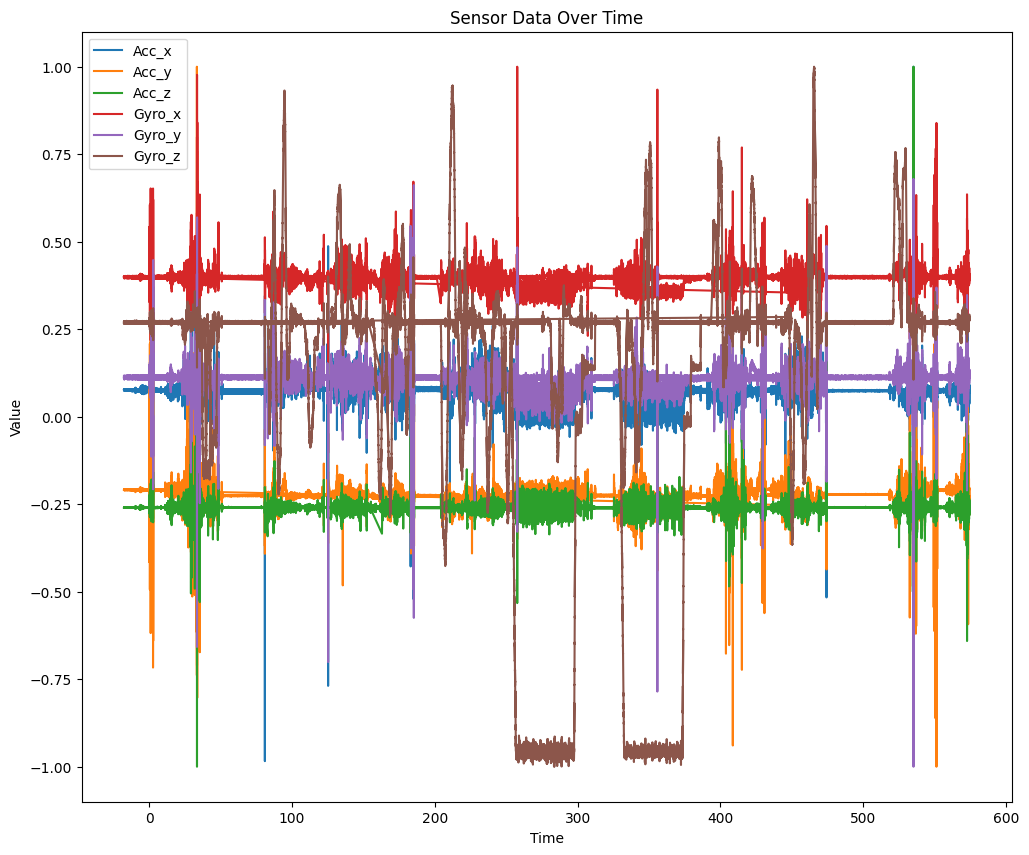

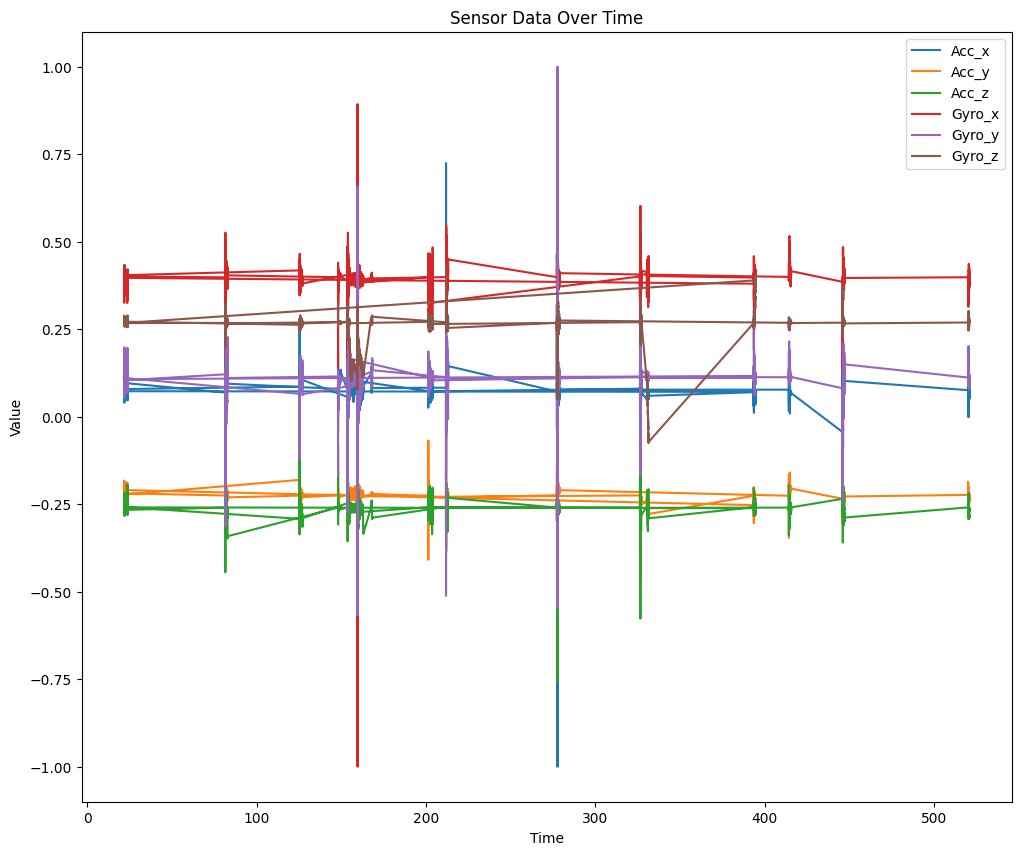

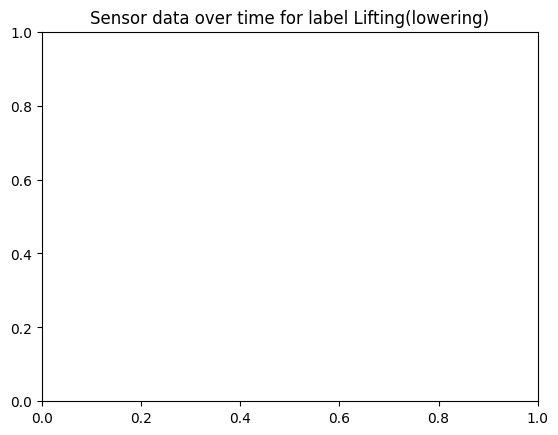

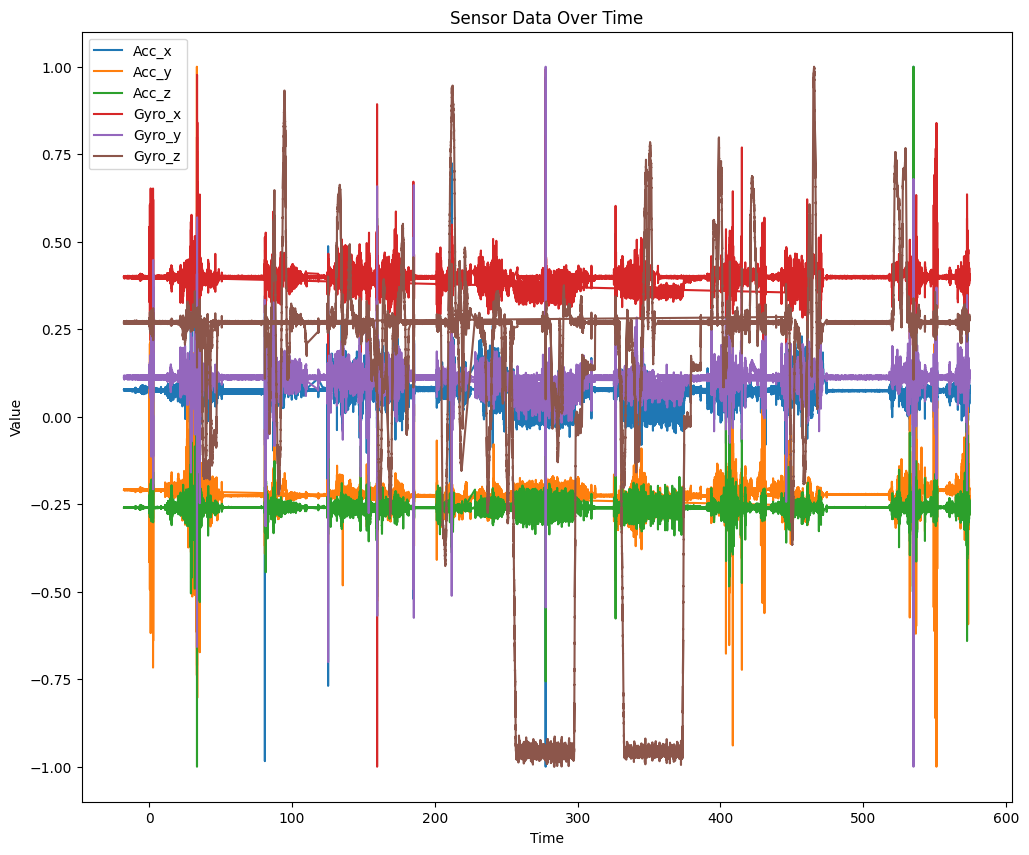

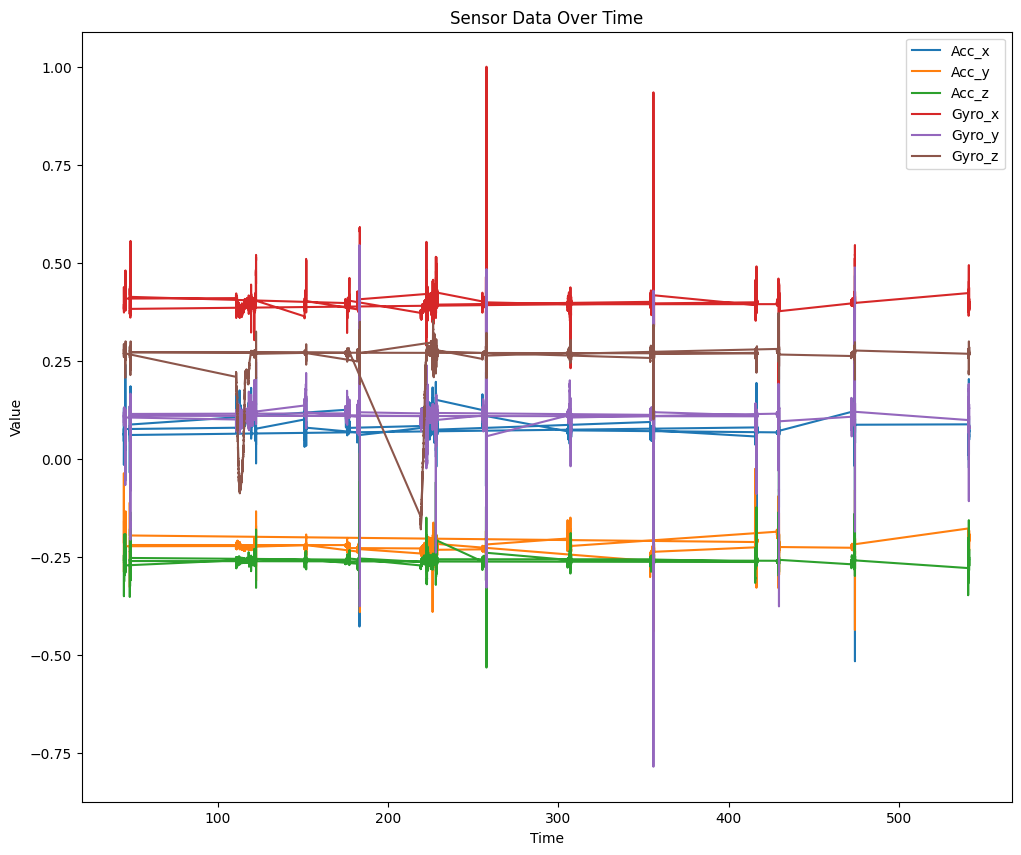

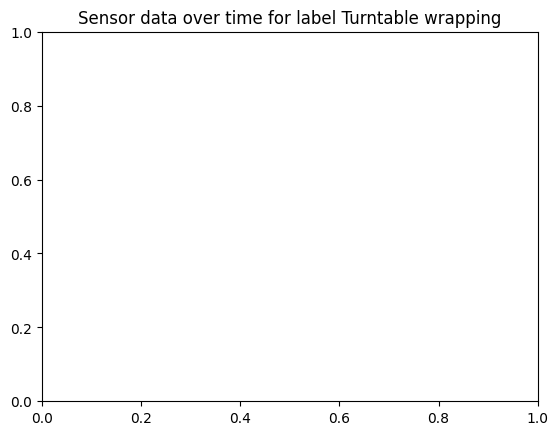

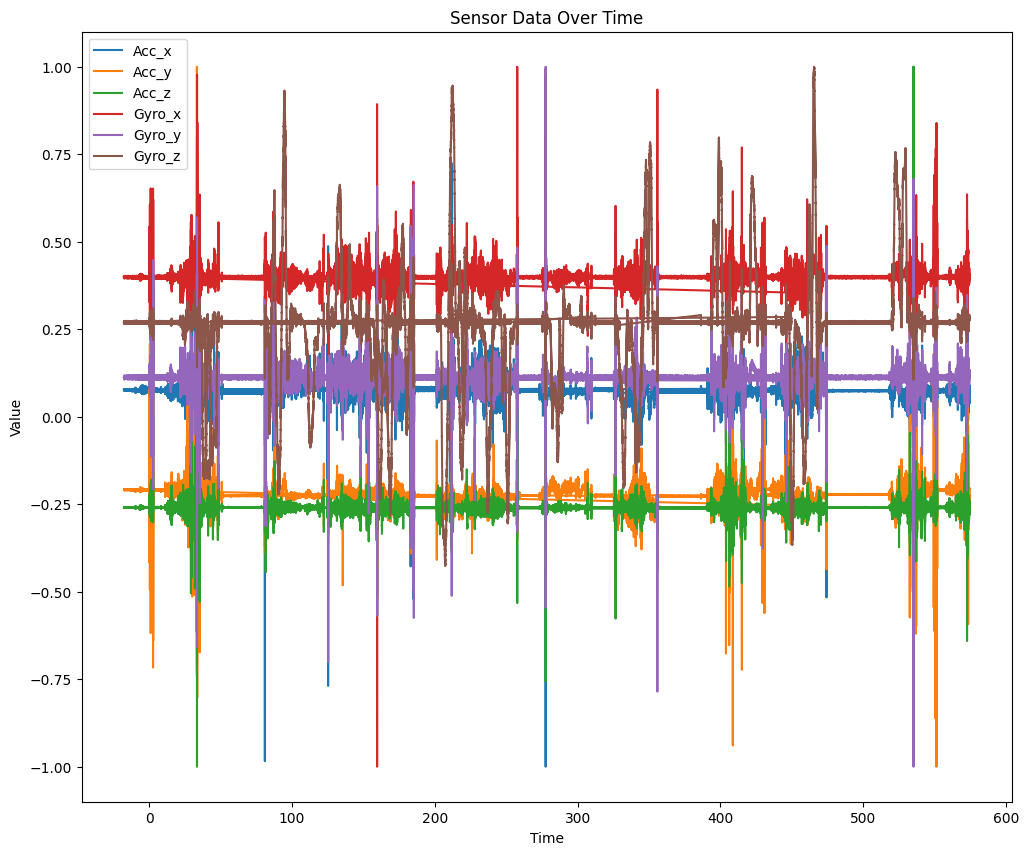

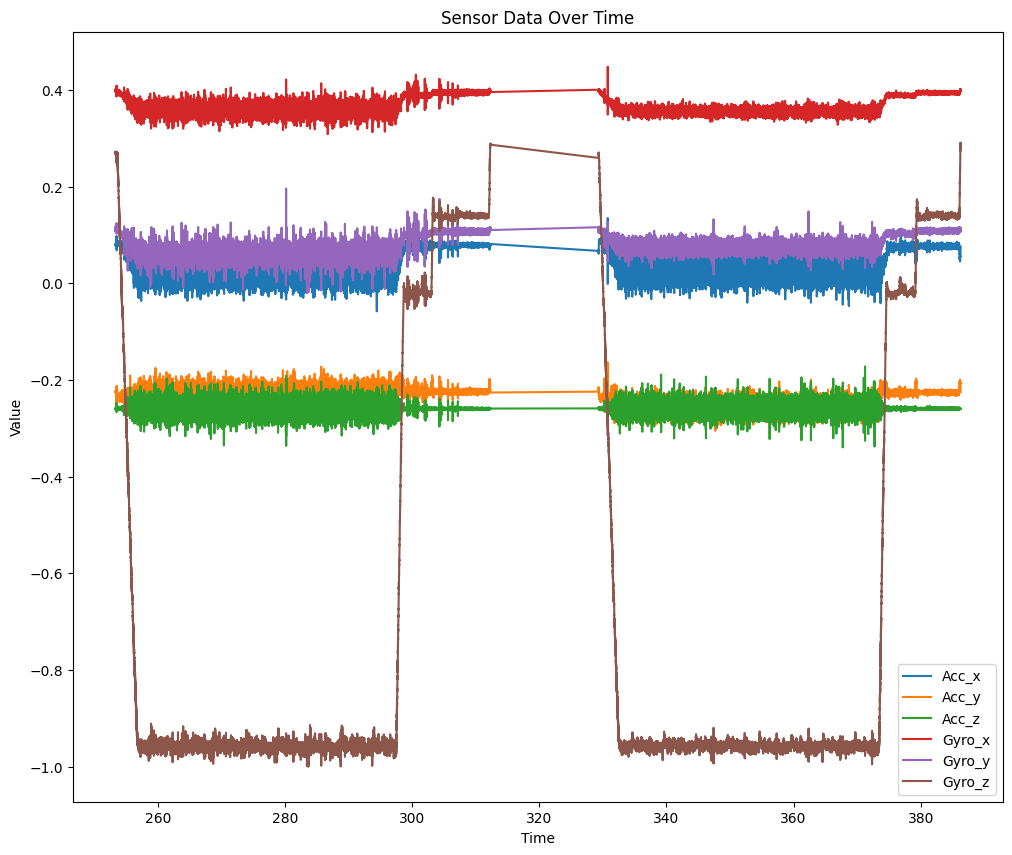

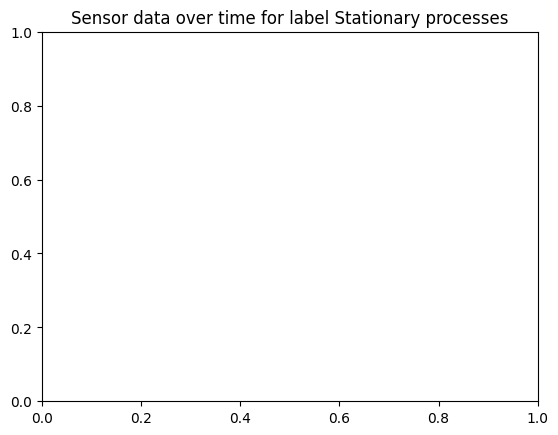

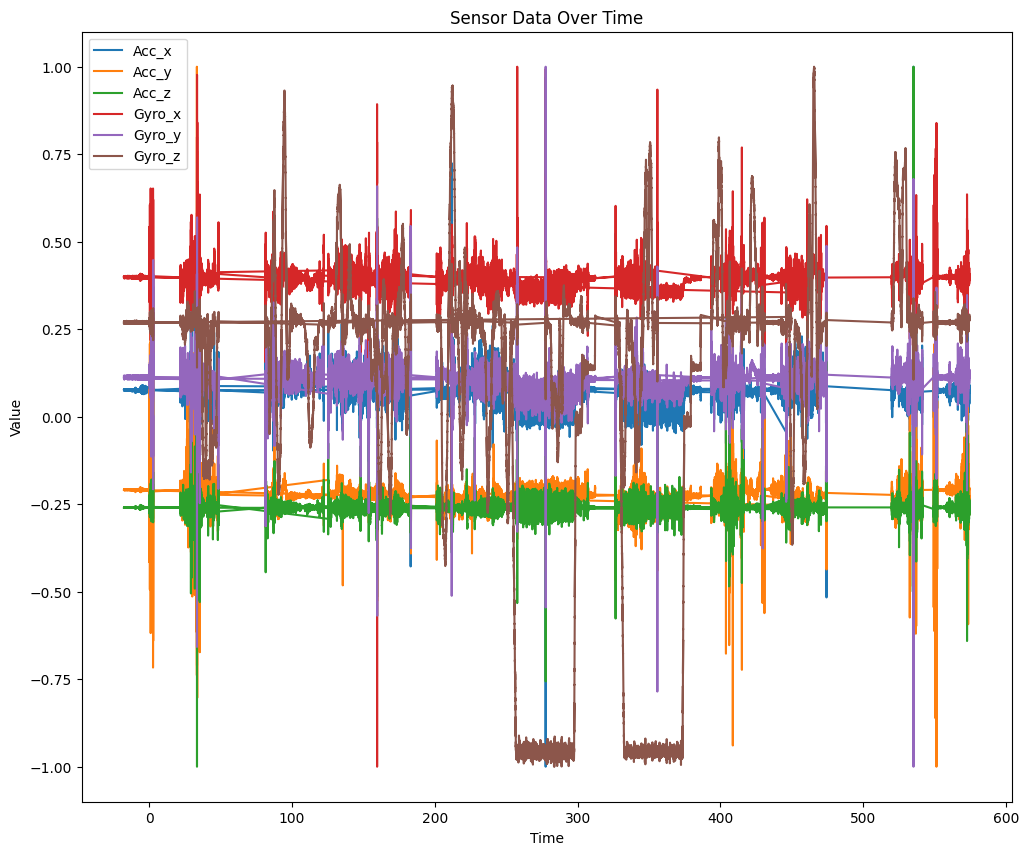

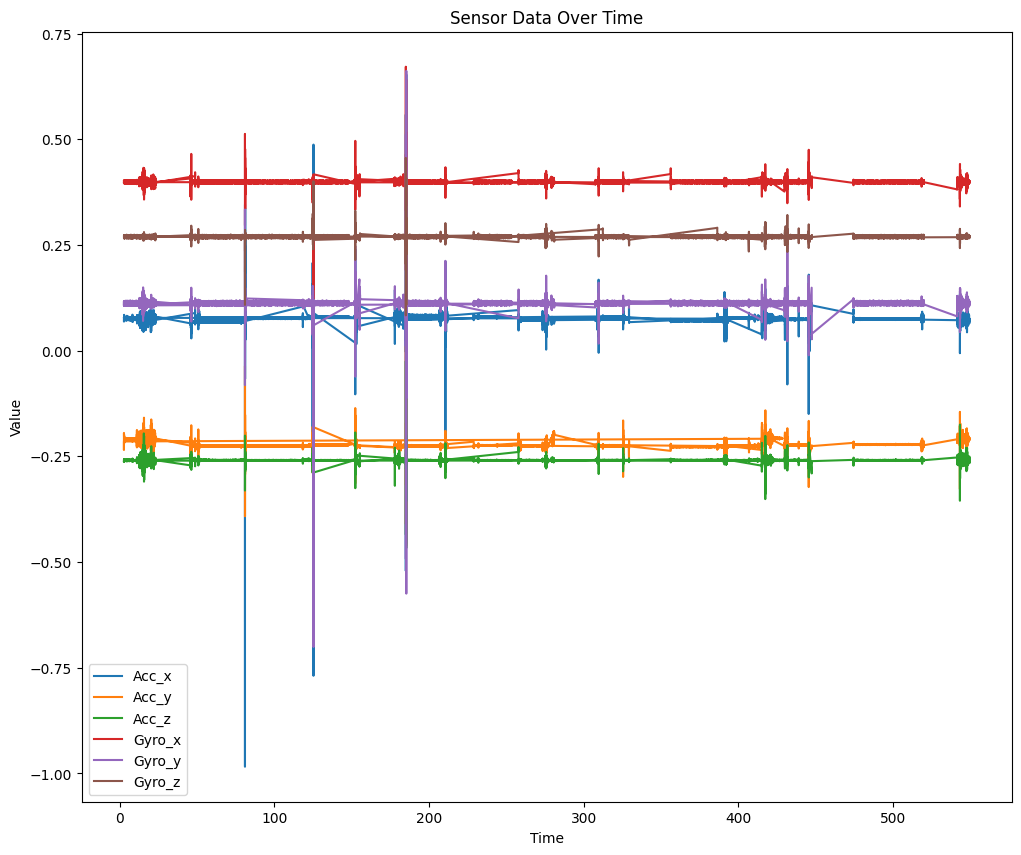

In [56]:
label_cols = y_train.columns.tolist()

plot_sensor_data_by_label(X_train, y_train, label_cols)